In [123]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime
import matplotlib.pyplot as plt


In [124]:
# ------------------------------
# CONFIG
# ------------------------------
PV_CSV_PATH = "merged_output2.csv"  # change to your csv filename
WEATHER_CSV_PATH = "weather_data.csv"
TIME_COL = "timestamp"
SEQ_LEN = 24            # encoder looks back 24 hours
HORIZON = 24            # forecast t+1 .. t+24
BATCH_SIZE = 8
EPOCHS = 10
LR = 0.001 
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRINT_EVERY = 1

In [125]:
TARGET_COL = "pv"
ALL_FEATURES = ["pv","sun_hours","temperature","glob_radiation_wm2", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "woy_sin","woy_cos"]
PAST_FEATURES = ["pv","sun_hours","temperature", "glob_radiation_wm2", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "woy_sin","woy_cos"]#
EXOG_FEATURES = ["temperature","sun_hours", "glob_radiation_wm2", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "woy_sin","woy_cos"]#

In [126]:
# ==== 1. Load PV data (5-min intervals) ====

# Parse timestamp index, ensure timezone-naive for alignment
pv_df = pd.read_csv(
    PV_CSV_PATH,
    sep=",",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

# Convert numeric
pv_df = pv_df.apply(pd.to_numeric, errors="coerce")

# ==== 2. Resample PV data to hourly ====
# Average SOC, PV, and Load over each hour
pv_hourly = pv_df.resample("1h").mean()

# ==== 3. Load weather data (already hourly) ====
weather_df = pd.read_csv(
    WEATHER_CSV_PATH,
    sep=",",
    parse_dates=["time"],
    index_col="time"
)

# Convert timezone-aware → naive UTC or local
if weather_df.index.tz is not None:
    weather_df.index = weather_df.index.tz_convert(None)

# Ensure numeric dtype
weather_df = weather_df.apply(pd.to_numeric, errors="coerce")

# ==== 4. Align start dates and merge ====
# Filter weather data starting from 2024-07-01
weather_df = weather_df.loc["2024-07-01":"2025-10-20"]

# Join on timestamp/hour
df = pv_hourly.join(weather_df, how="inner")

# --- Add time features ---
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["weekofyear"] = df.index.isocalendar().week

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["woy_sin"] = np.sin(2 * np.pi * df["weekofyear"] / 52)
df["woy_cos"]= np.cos(2 * np.pi * df["weekofyear"] / 52)

df = df[ALL_FEATURES]

# ==== 5. Optional sanity checks ====
print("Merged shape:", df.shape)
print(df.head(5))
print(df.tail(5))

# Check for missing values
missing = df.isna().sum()
print("\nMissing values per column:\n", missing)

df = df.replace(["None", "nan", "NaN", ""], pd.NA)
df = df.ffill().bfill()

df.info()

C:\Users\chris\AppData\Local\Temp\ipykernel_35216\3746056550.py:4: DtypeWarning: Columns (3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  pv_df = pd.read_csv(


Merged shape: (11448, 10)
                      pv  sun_hours  temperature  glob_radiation_wm2  \
2024-07-01 00:00:00  0.0        0.0         20.8                   0   
2024-07-01 01:00:00  0.0        0.0         20.8                   0   
2024-07-01 02:00:00  0.0        0.0         20.5                   0   
2024-07-01 03:00:00  0.0        0.0         20.2                   0   
2024-07-01 04:00:00  0.0        0.0         20.1                  18   

                     hour_sin  hour_cos  dow_sin  dow_cos   woy_sin   woy_cos  
2024-07-01 00:00:00  0.000000  1.000000      0.0      1.0 -0.120537 -0.992709  
2024-07-01 01:00:00  0.258819  0.965926      0.0      1.0 -0.120537 -0.992709  
2024-07-01 02:00:00  0.500000  0.866025      0.0      1.0 -0.120537 -0.992709  
2024-07-01 03:00:00  0.707107  0.707107      0.0      1.0 -0.120537 -0.992709  
2024-07-01 04:00:00  0.866025  0.500000      0.0      1.0 -0.120537 -0.992709  
                           pv  sun_hours  temperature  glob_r

In [127]:
print(df["pv"].idxmax())
print(max(df["pv"]))

2024-07-04 15:00:00
6.495833333333334


In [128]:
# --- Split sets ---
split_train = int(len(df) * 0.7)
split_val = int(len(df) * 0.85)
df_train = df.iloc[:split_train]
df_val = df.iloc[split_train:split_val]
df_test = df.iloc[split_val:]

# --- Fit scalers ---
scaler_pv = StandardScaler()
scaler_X = StandardScaler()
scaler_exog = StandardScaler()

scaler_pv.fit(df_train[[TARGET_COL]])
scaler_X.fit(df_train[PAST_FEATURES])
scaler_exog.fit(df_train[EXOG_FEATURES])

# --- Apply scaling ---
df_scaled = pd.DataFrame(index=df.index)
df_scaled[TARGET_COL] = scaler_pv.transform(df[[TARGET_COL]]).flatten()
df_scaled[PAST_FEATURES] = scaler_X.transform(df[PAST_FEATURES])
df_scaled[EXOG_FEATURES] = scaler_exog.transform(df[EXOG_FEATURES])

# Final check
print("Scaled min/max (pv):", df_scaled["pv"].min(), df_scaled["pv"].max())
print("Scaled sample:\n", df_scaled.head())

Scaled min/max (pv): -0.5874771422873193 3.6835514934365214
Scaled sample:
                            pv  sun_hours  temperature  glob_radiation_wm2  \
2024-07-01 00:00:00 -0.587477   -0.58851     1.082244           -0.615907   
2024-07-01 01:00:00 -0.587477   -0.58851     1.082244           -0.615907   
2024-07-01 02:00:00 -0.587477   -0.58851     1.048922           -0.615907   
2024-07-01 03:00:00 -0.587477   -0.58851     1.015599           -0.615907   
2024-07-01 04:00:00 -0.587477   -0.58851     1.004491           -0.529830   

                     hour_sin  hour_cos   dow_sin   dow_cos   woy_sin  \
2024-07-01 00:00:00 -0.000259  1.414782 -0.007683  1.413225 -0.139714   
2024-07-01 01:00:00  0.365736  1.366590 -0.007683  1.413225 -0.139714   
2024-07-01 02:00:00  0.706788  1.225298 -0.007683  1.413225 -0.139714   
2024-07-01 03:00:00  0.999656  1.000534 -0.007683  1.413225 -0.139714   
2024-07-01 04:00:00  1.224382  0.707615 -0.007683  1.413225 -0.139714   

                      

In [129]:
class SequenceDataset(Dataset):
    def __init__(self, df, seq_len, horizon):
        self.X_past = df[PAST_FEATURES].values
        self.X_exog = df[EXOG_FEATURES].values
        self.y = df[[TARGET_COL]].values
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self):
        return len(self.X_past) - self.seq_len - self.horizon

    def __getitem__(self, idx):
        x_hist = self.X_past[idx:idx+self.seq_len]
        x_exog_future = self.X_exog[idx+self.seq_len:idx+self.seq_len+self.horizon]
        y_future = self.y[idx+self.seq_len:idx+self.seq_len+self.horizon]
        return (
            torch.tensor(x_hist, dtype=torch.float32),
            torch.tensor(x_exog_future, dtype=torch.float32),
            torch.tensor(y_future, dtype=torch.float32)
        )

train_ds = SequenceDataset(df_scaled.iloc[:split_train], SEQ_LEN, HORIZON)
val_ds   = SequenceDataset(df_scaled.iloc[split_train:split_val], SEQ_LEN, HORIZON)
test_ds  = SequenceDataset(df_scaled.iloc[split_val:], SEQ_LEN, HORIZON)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


In [130]:
df_test.shape

(1718, 10)

In [131]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=NUM_LAYERS, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
    def forward(self, x):
        _, (h, c) = self.lstm(x)
        return h, c


class Decoder(nn.Module):
    def __init__(self, hidden_size, exog_size, num_layers=NUM_LAYERS, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1 + exog_size, hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h, c, exog_future, y_future=None, teacher_forcing_ratio=0.5):
        batch_size, horizon, _ = exog_future.shape
        device = exog_future.device
        outputs = []
        prev = torch.zeros(batch_size, 1, device=device)

        for t in range(horizon):
            exog_t = exog_future[:, t, :]                 # (batch, exog_size)
            inp = torch.cat([prev, exog_t], dim=1).unsqueeze(1)
            out, (h, c) = self.lstm(inp, (h, c))
            pred = self.fc(self.dropout(out.squeeze(1)))  # (batch,1)
            outputs.append(pred)

            # Scheduled sampling
            if self.training and y_future is not None and torch.rand(1).item() < teacher_forcing_ratio:
                prev = y_future[:, t]
            else:
                prev = pred
        return torch.stack(outputs, dim=1)


class Seq2Seq(nn.Module):
    def __init__(self, input_size, hidden_size, exog_size, dropout=0.2):
        super().__init__()
        self.encoder = Encoder(input_size, hidden_size, dropout=dropout)
        self.decoder = Decoder(hidden_size, exog_size, dropout=dropout)

    def forward(self, x_hist, x_exog_future, y_future=None, teacher_forcing_ratio=0.5):
        h, c = self.encoder(x_hist)
        out = self.decoder(h, c, x_exog_future, y_future, teacher_forcing_ratio)
        return out

In [132]:
def train_model(model, train_loader, val_loader, n_epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        tf_ratio = max(0.05, 0.7 * (1 - epoch / n_epochs))  # scheduled TF

        for x_hist, x_exog_future, y in train_loader:
            x_hist, x_exog_future, y = x_hist.to(device), x_exog_future.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x_hist, x_exog_future, y, teacher_forcing_ratio=tf_ratio)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_hist, x_exog_future, y in val_loader:
                x_hist, x_exog_future, y = x_hist.to(device), x_exog_future.to(device), y.to(device)
                pred = model(x_hist, x_exog_future, teacher_forcing_ratio=0)
                val_loss += criterion(pred, y).item()

        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {total_loss/len(train_loader):.6f} "
              f"| Val Loss: {val_loss/len(val_loader):.6f} | TF ratio: {tf_ratio:.3f}")


In [138]:
def evaluate(model, test_loader, scaler_pv):
    model.eval()
    preds, trues = [], []
    device = next(model.parameters()).device

    with torch.no_grad():
        for x_hist, x_exog_future, y in test_loader:
            x_hist, x_exog_future, y = x_hist.to(device), x_exog_future.to(device), y.to(device)
            pred = model(x_hist, x_exog_future, teacher_forcing_ratio=0)
            preds.append(pred.cpu().numpy())
            trues.append(y.cpu().numpy())

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)

    preds_unscaled = scaler_pv.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    trues_unscaled = scaler_pv.inverse_transform(trues.reshape(-1, 1)).reshape(trues.shape)

    horizons = [1, 3, 6, 12,24]
    rmses, maes = [], []

    for h in horizons:
        rmse = np.sqrt(np.mean((preds_unscaled[:, h-1] - trues_unscaled[:, h-1]) ** 2))
        mae = np.mean(np.abs(preds_unscaled[:, h-1] - trues_unscaled[:, h-1]))
        rmses.append(rmse)
        maes.append(mae)
        print(f"H+{h}: RMSE={rmse:.3f}, MAE={mae:.3f}")

    overall_rmse = np.sqrt(np.mean((preds_unscaled - trues_unscaled) ** 2))
    overall_mae = np.mean(np.abs(preds_unscaled - trues_unscaled))
    print(f"Overall RMSE={overall_rmse:.3f}, MAE={overall_mae:.3f}")
    overall_r2 = r2_score(
    trues_unscaled.reshape(-1),
    preds_unscaled.reshape(-1))

    print(f"Overall R2={overall_r2:.3f}")

    # --- Plot RMSE/MAE per horizon ---
    plt.figure(figsize=(7, 4))
    plt.plot(horizons, rmses, marker="o", label="RMSE")
    plt.xlabel("Forecast Horizon (hours ahead)")
    plt.ylabel("Error")
    plt.title("Forecast Error by Horizon")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot sample prediction vs actual ---
    idx = np.random.randint(0, len(preds_unscaled))
    plt.figure(figsize=(8, 4))
    plt.plot(trues_unscaled[idx], label="True PV")
    plt.plot(preds_unscaled[idx], label="Predicted PV")
    plt.title("Example 24-hour Forecast")
    plt.xlabel("Hour Ahead")
    plt.ylabel("PV")
    plt.legend()
    plt.show()

In [134]:
model = Seq2Seq(input_size=len(PAST_FEATURES), hidden_size=HIDDEN_SIZE,
                exog_size=len(EXOG_FEATURES), dropout=0.2)



C:\Users\chris\OneDrive\Dokumente\FH MDS\Semester3\Artificial Intelligence\pytorch-venv\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [135]:
train_model(model, train_loader, val_loader, n_epochs=10, lr=LR)


Epoch 1/10 | Train Loss: 0.072099 | Val Loss: 0.055888 | TF ratio: 0.700
Epoch 2/10 | Train Loss: 0.039544 | Val Loss: 0.048297 | TF ratio: 0.630
Epoch 3/10 | Train Loss: 0.035651 | Val Loss: 0.048972 | TF ratio: 0.560
Epoch 4/10 | Train Loss: 0.033438 | Val Loss: 0.048056 | TF ratio: 0.490
Epoch 5/10 | Train Loss: 0.031923 | Val Loss: 0.049324 | TF ratio: 0.420
Epoch 6/10 | Train Loss: 0.030211 | Val Loss: 0.049756 | TF ratio: 0.350
Epoch 7/10 | Train Loss: 0.028988 | Val Loss: 0.049907 | TF ratio: 0.280
Epoch 8/10 | Train Loss: 0.027817 | Val Loss: 0.050753 | TF ratio: 0.210
Epoch 9/10 | Train Loss: 0.025581 | Val Loss: 0.053051 | TF ratio: 0.140
Epoch 10/10 | Train Loss: 0.024122 | Val Loss: 0.053187 | TF ratio: 0.070


H+1: RMSE=0.448, MAE=0.218
H+3: RMSE=0.533, MAE=0.245
H+6: RMSE=0.543, MAE=0.251
H+12: RMSE=0.546, MAE=0.250
H+24: RMSE=0.565, MAE=0.261
Overall RMSE=0.547, MAE=0.252
Overall R2=0.873


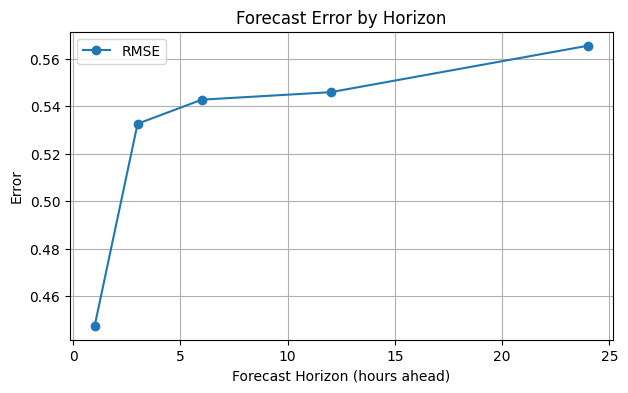

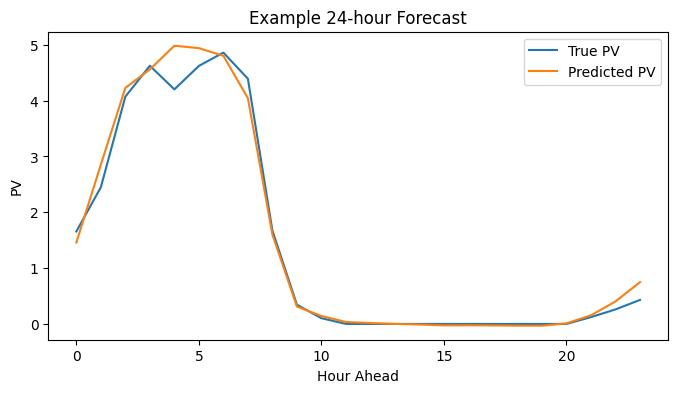

In [139]:
evaluate(model, test_loader, scaler_pv)